In [8]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [9]:
import os

if os.path.basename(os.getcwd()) == 'plots':
    os.chdir('..')

import matplotlib.pyplot as plt
import mplhep as hep
from coffea.util import load
from plots import hep_plot as hplot
from plots.hep_plot import CMS_COLORS
import hist

hplot.setup(era="2024")
print("HEP plot is set to 2024")

In [10]:
eras = ['2024C', '2024D', '2024E', '2024F', '2024G', '2024H']
outputs = [load(f'./outputs/dy/data_{era}_noSyst.coffea') for era in eras]

def _plot_axis_name(h):
    axis_names = [axis.name for axis in h.axes]
    candidates = [name for name in axis_names if name not in {'systematic', 'anacat'}]
    if len(candidates) != 1:
        raise ValueError(f'Could not identify one plot axis from {axis_names}')
    return candidates[0]

def get_hist(var, anacat_id=None, syst='nominal'):
    """Fetch histogram `var` from all eras, project to 1D, and sum."""
    hists = []
    for o in outputs:
        h = o[var][syst, ...]
        axis_name = _plot_axis_name(h)
        if anacat_id is not None:
            h = h[anacat_id, :].project(axis_name)
        else:
            h = h.project(axis_name)
        hists.append(h)
    result = hists[0]
    
    for h in hists[1:]:
        result = result + h
    return result

In [11]:
cat_map = outputs[-1]['analysisCategories']
cat_map

{0: 'atcen', 1: 'atfwd', 2: '2tcen', 3: '2tfwd'}

## $m_{t\bar{t}}$ per Analysis Category

## Jet Soft-Drop Mass

In [5]:
outputs[-1].keys()

dict_keys(['ttbarmass', 'mtt_unwgt', 'mtt_vs_mt', 'numerator', 'denominator', 'jetmass', 'jetmsd', 'jetdy', 'jetmass1', 'jetmsd1', 'dR_min_jet2', 'jet0_pt', 'jet0_eta', 'jet0_phi', 'jet0_rapidity', 'jet1_pt', 'jet1_eta', 'jet1_phi', 'jet1_rapidity', 'gen_mt', 'gen_mttbar', 'jet0_gen_dr', 'jet1_gen_dr', 'jet_mass_resolution', 'gen_jetmsd_reco_jetmsd', 'ht', 'cutflow', 'weights', 'systematics', 'event_list', 'truthstudy', 'analysisCategories'])

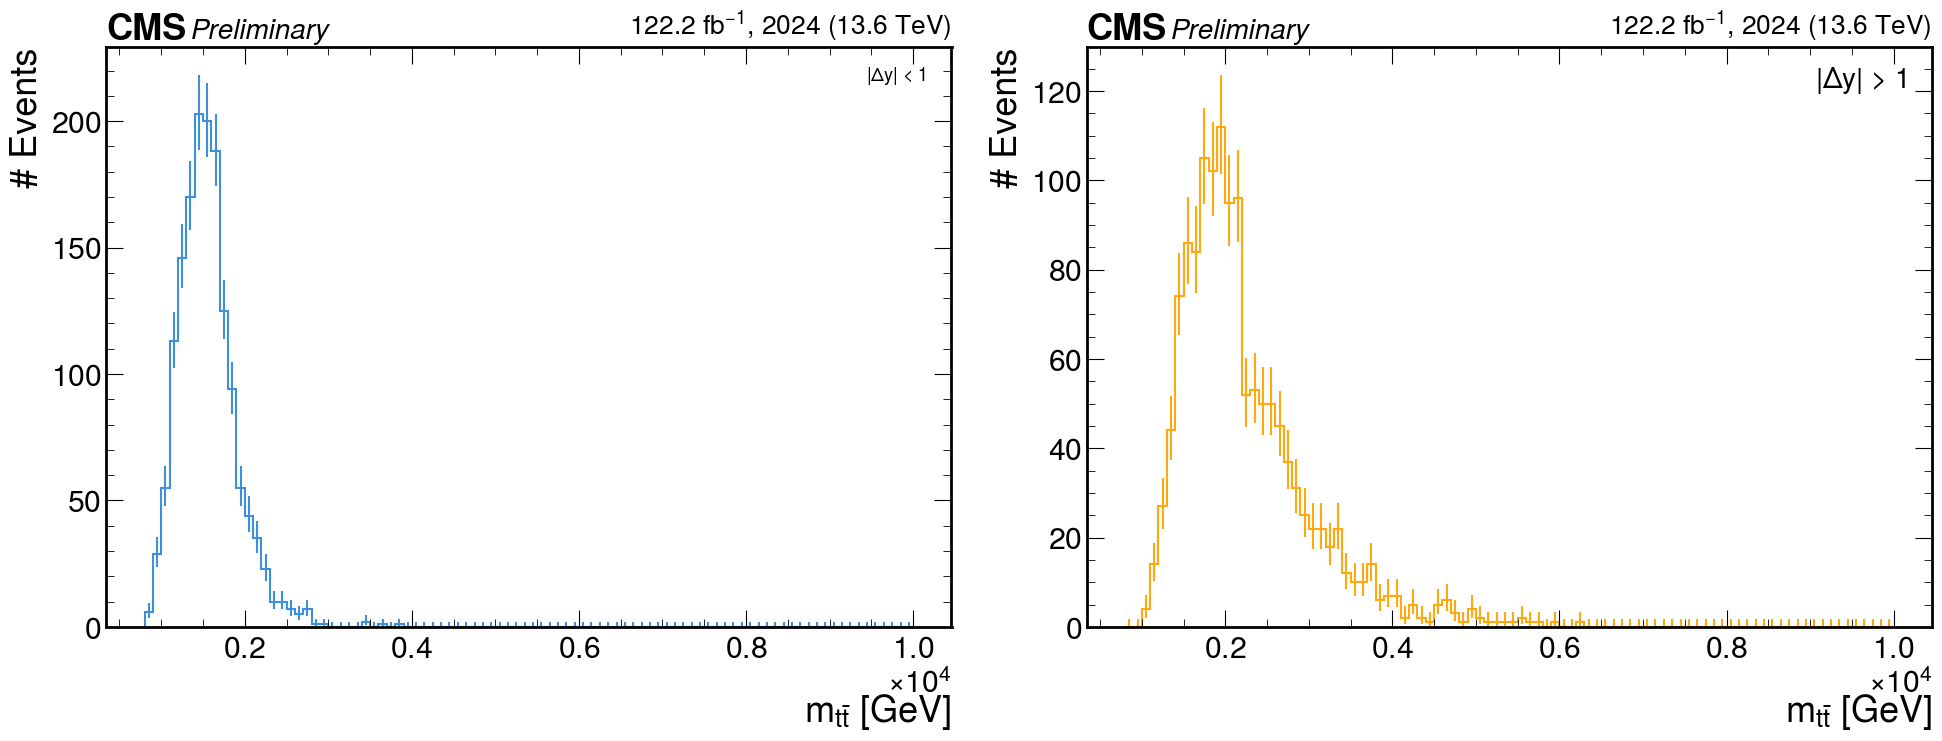

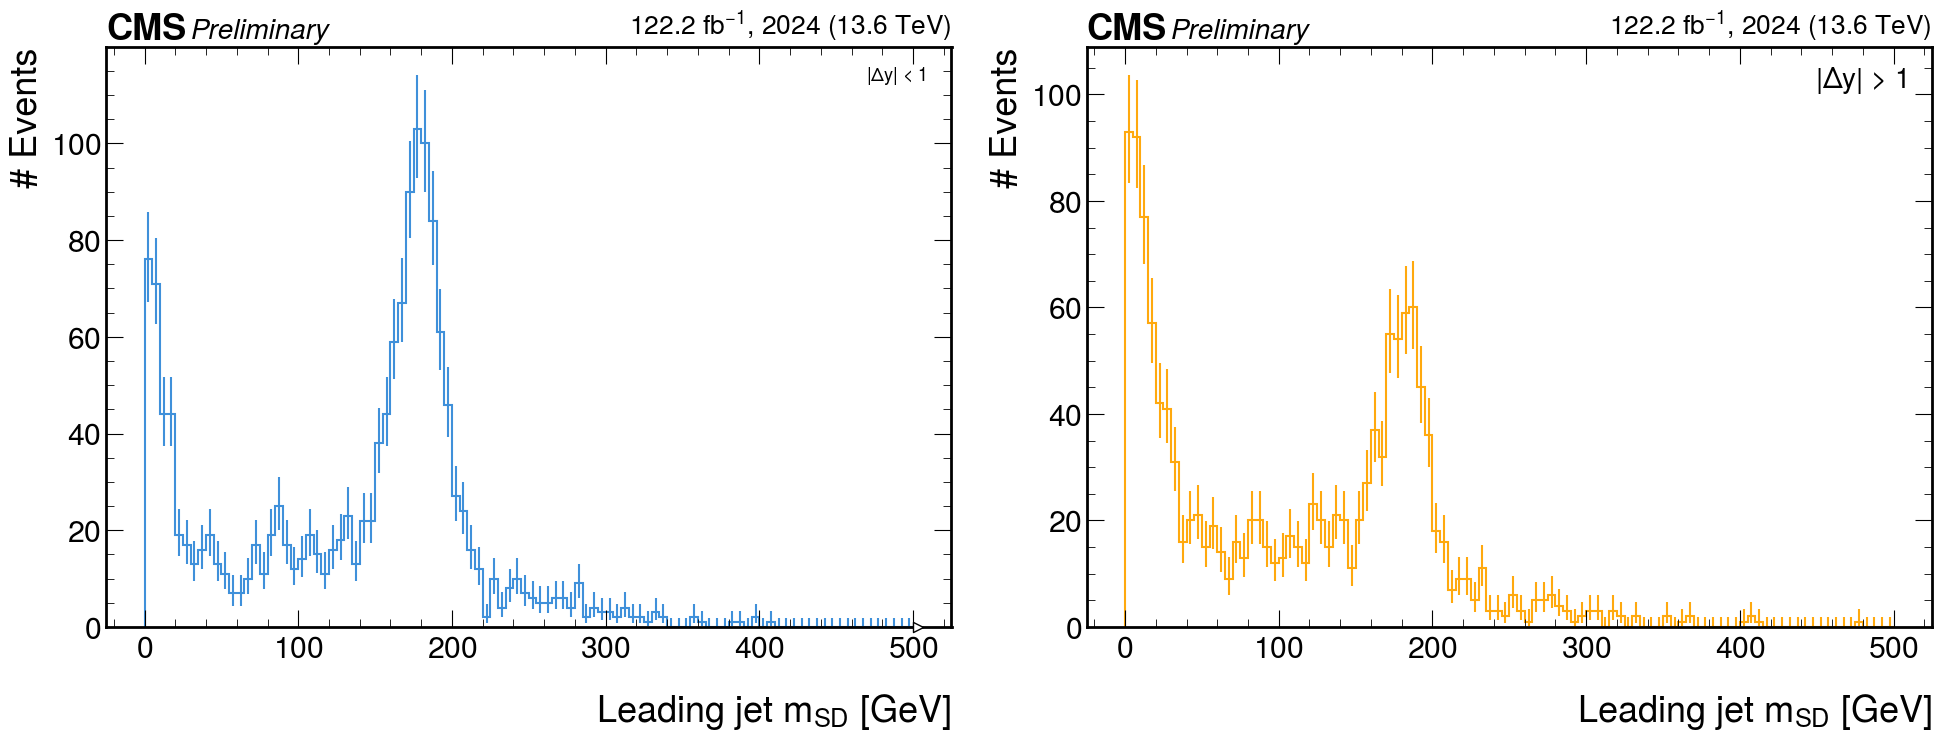

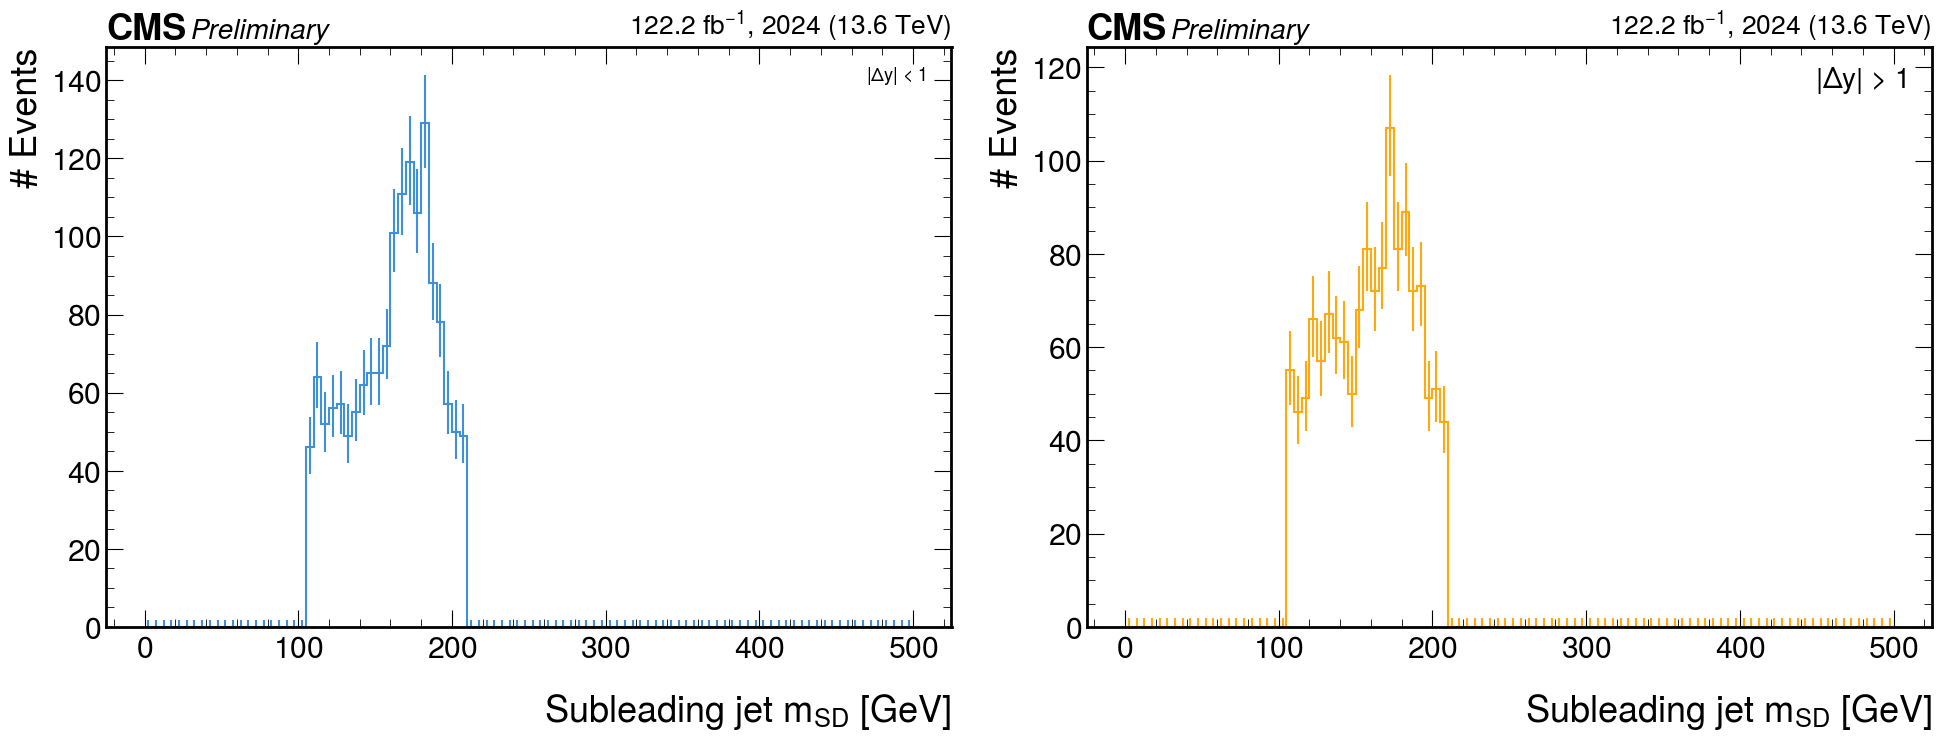

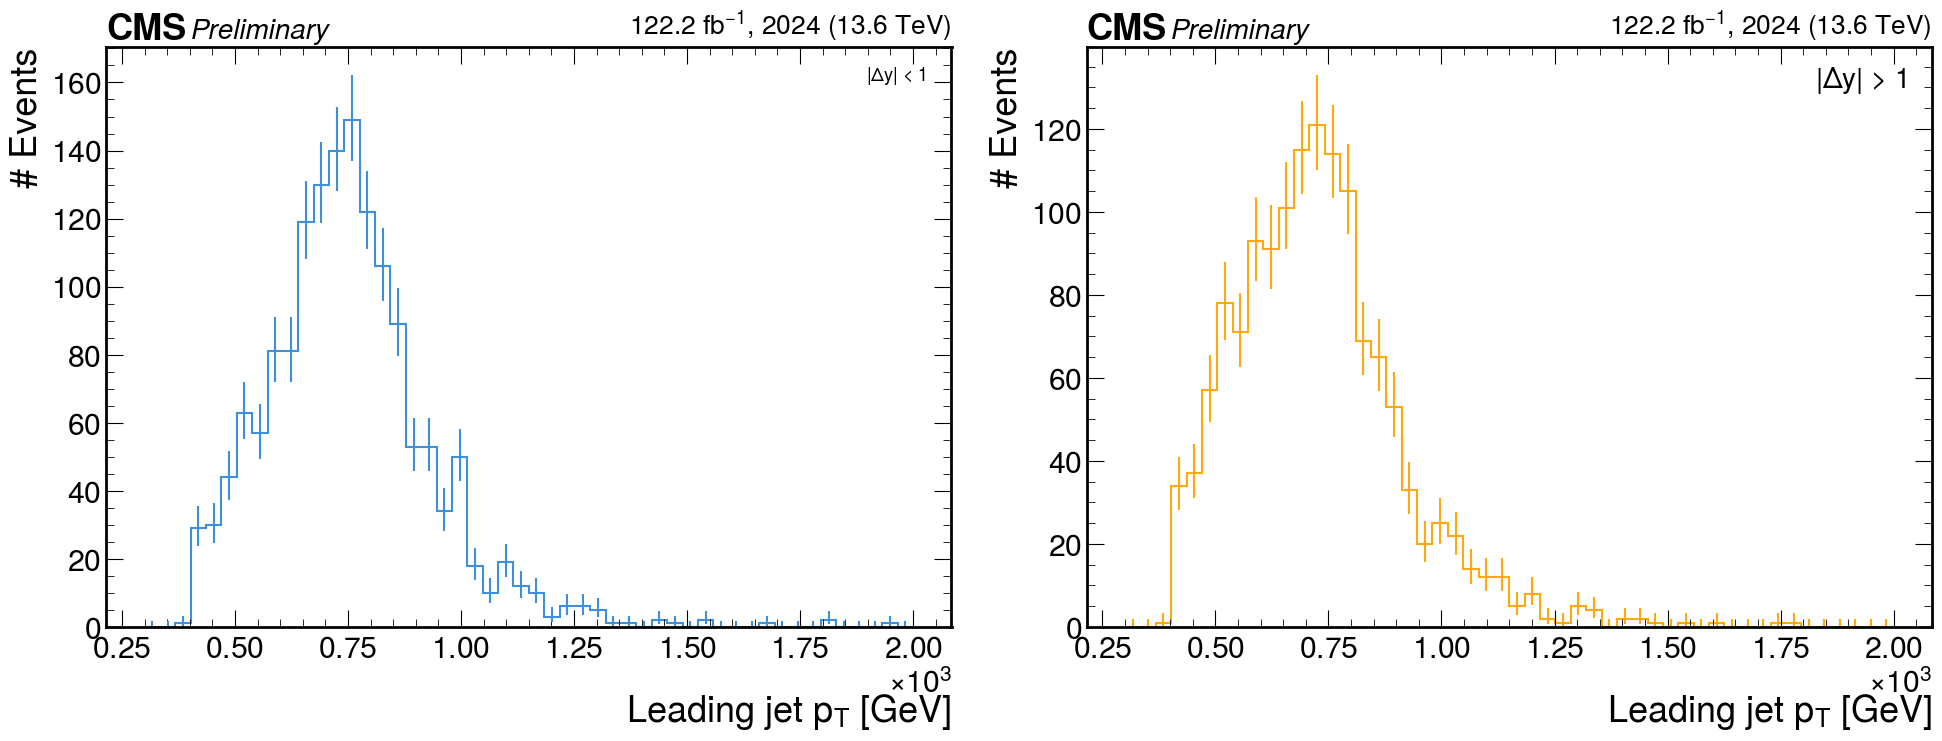

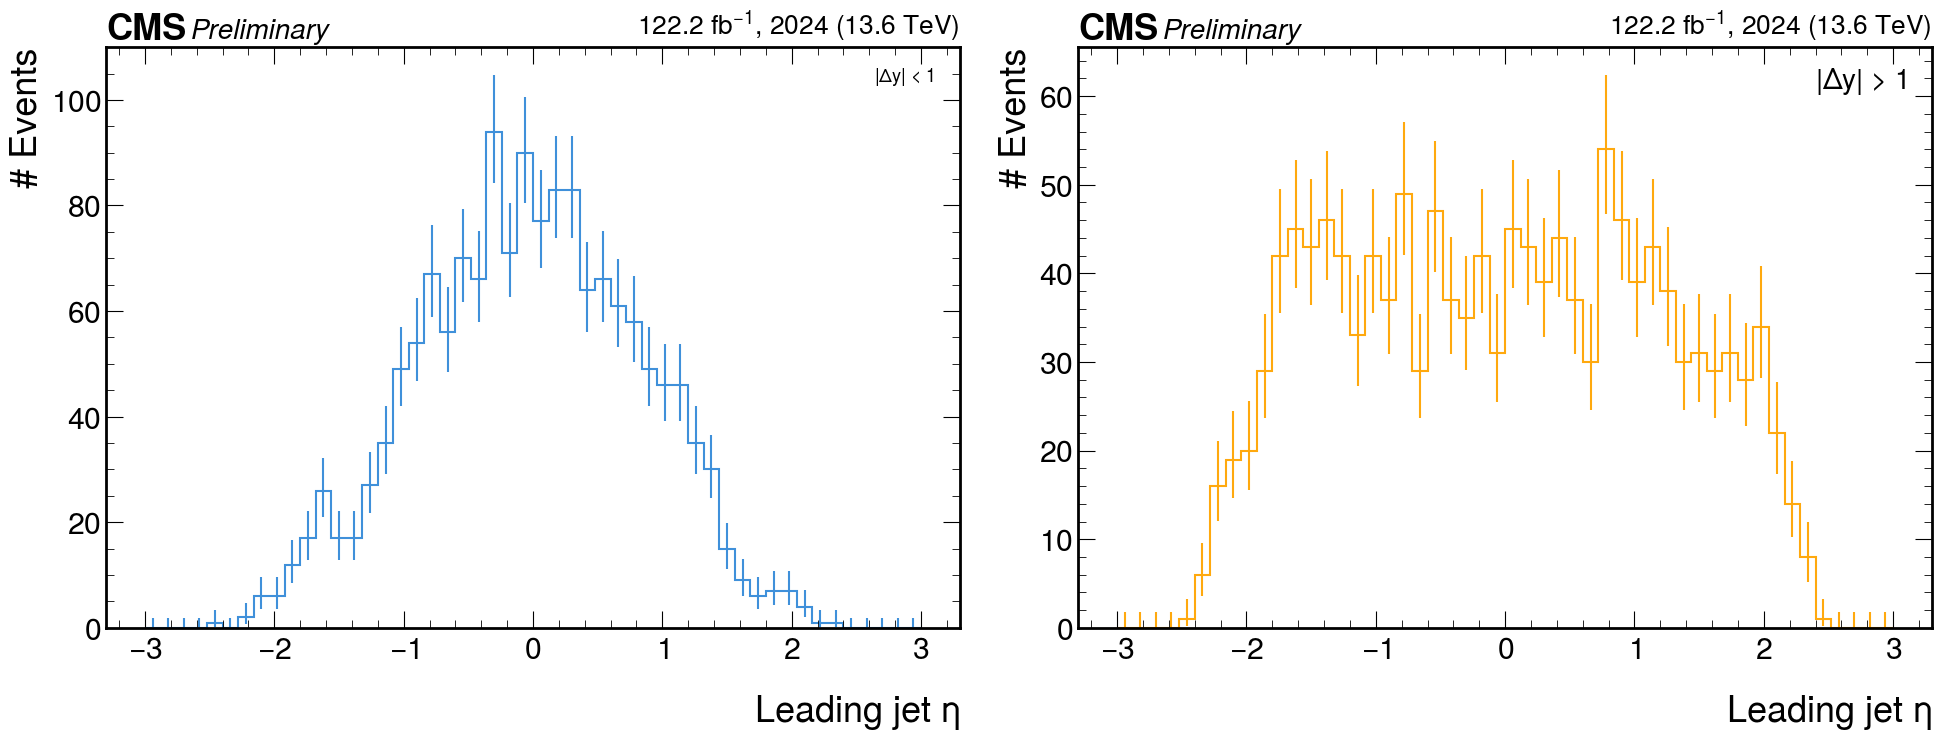

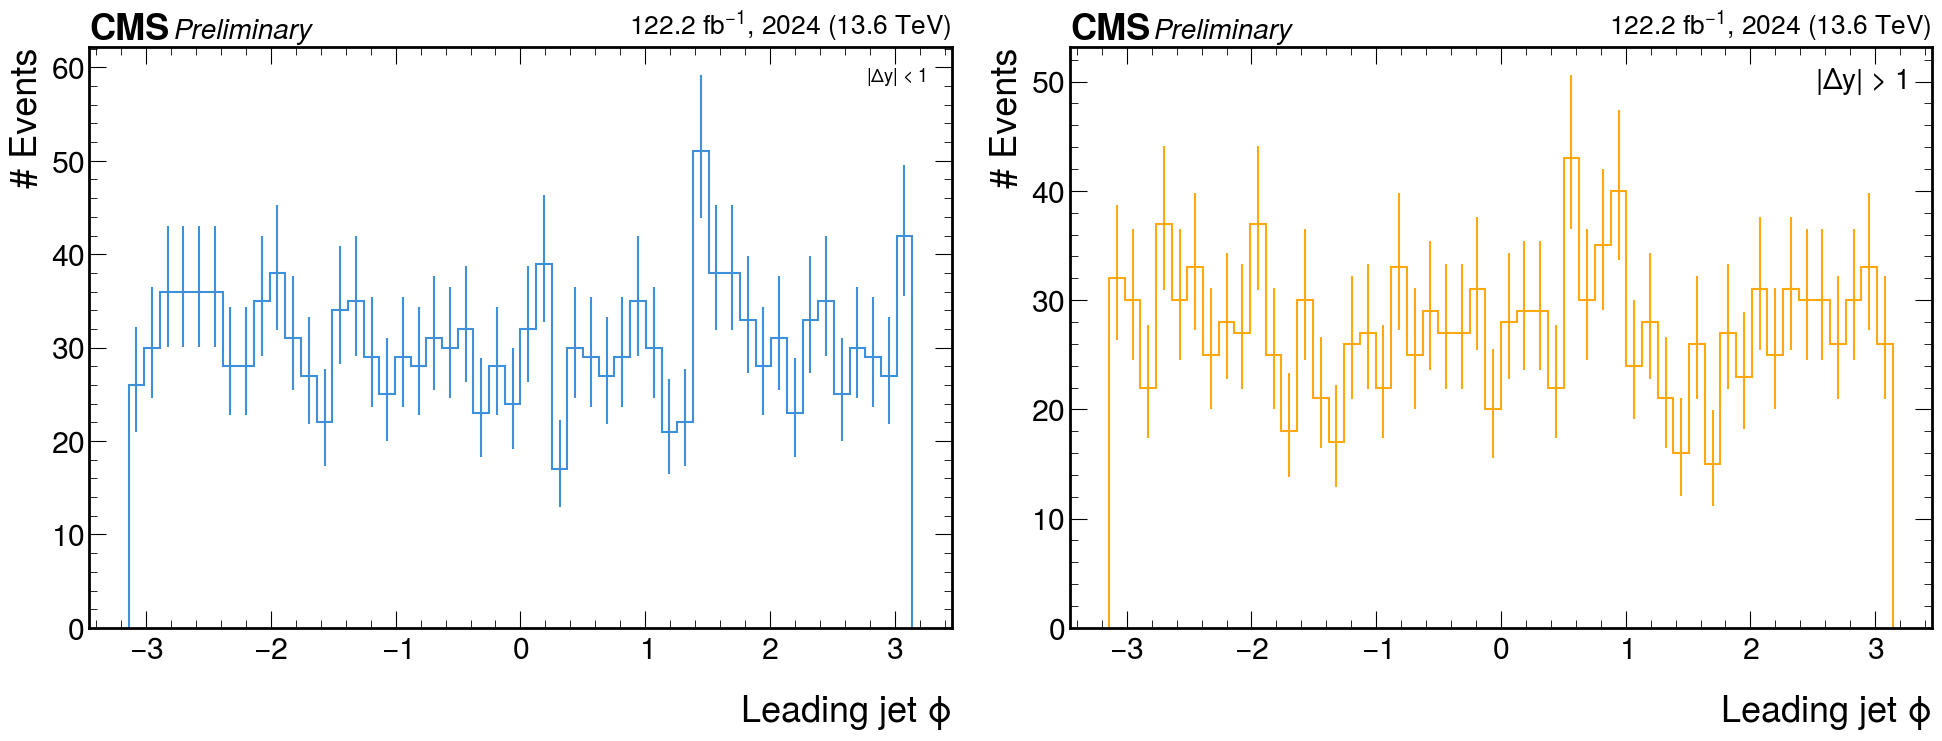

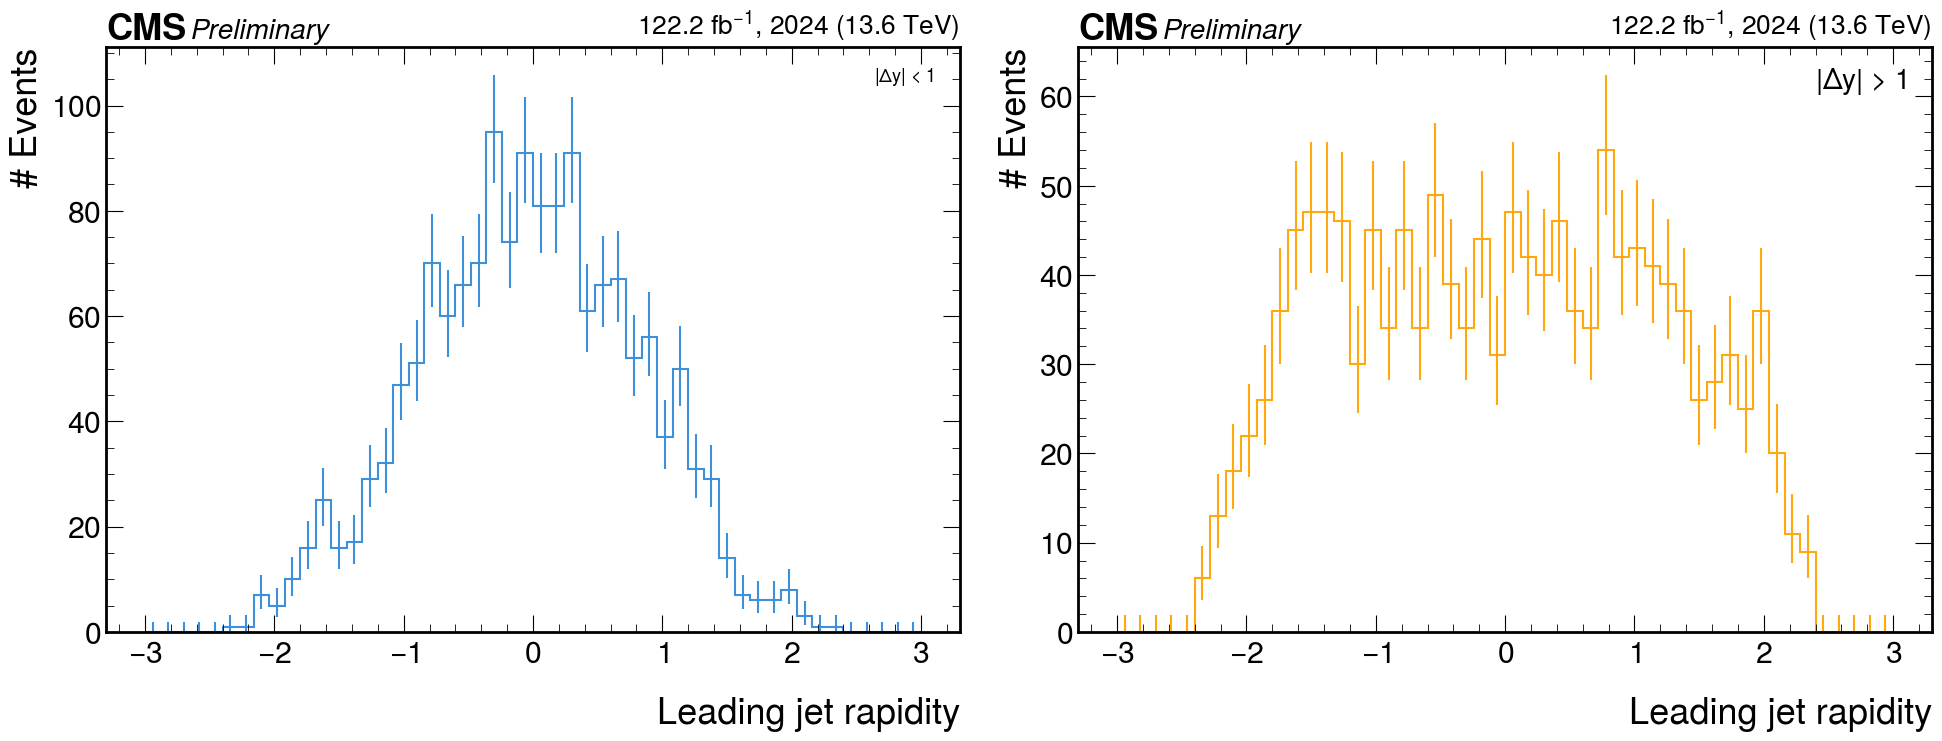

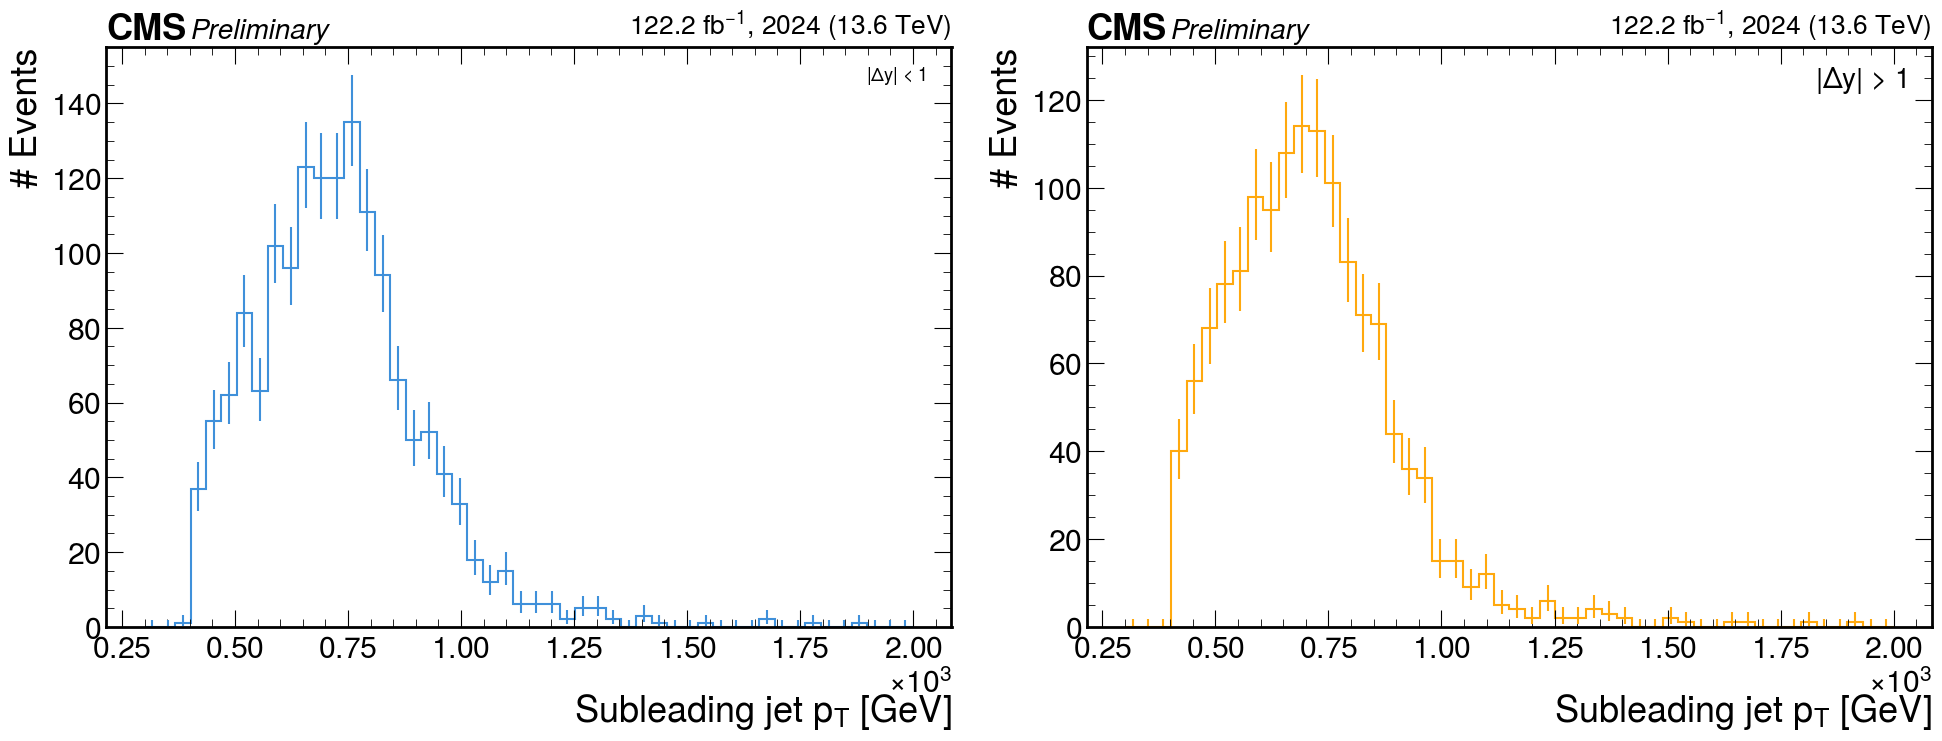

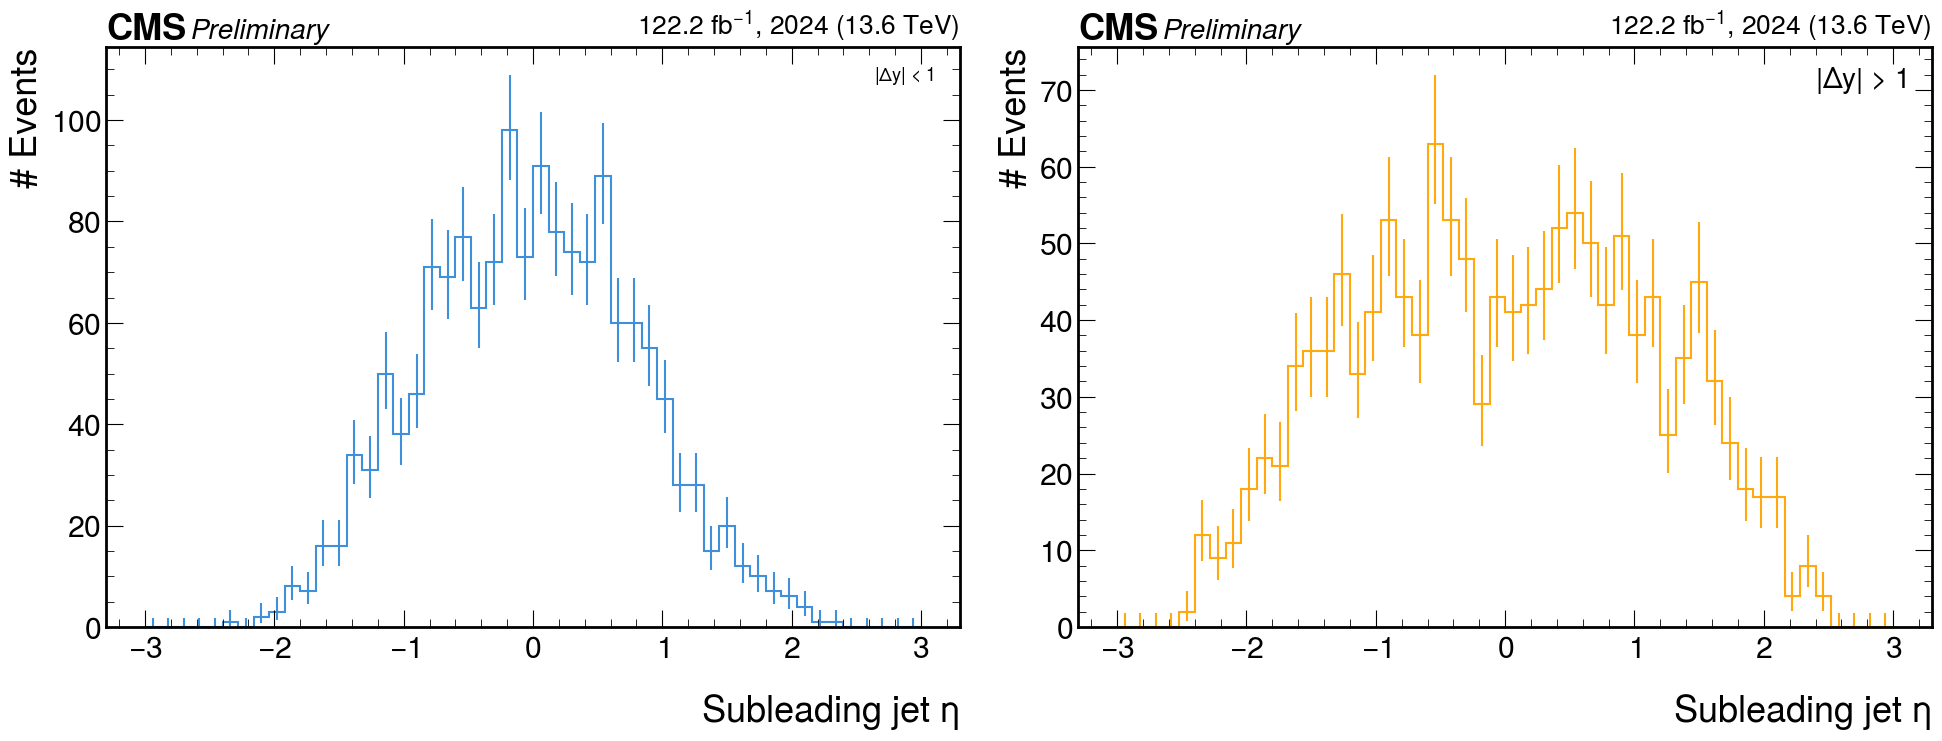

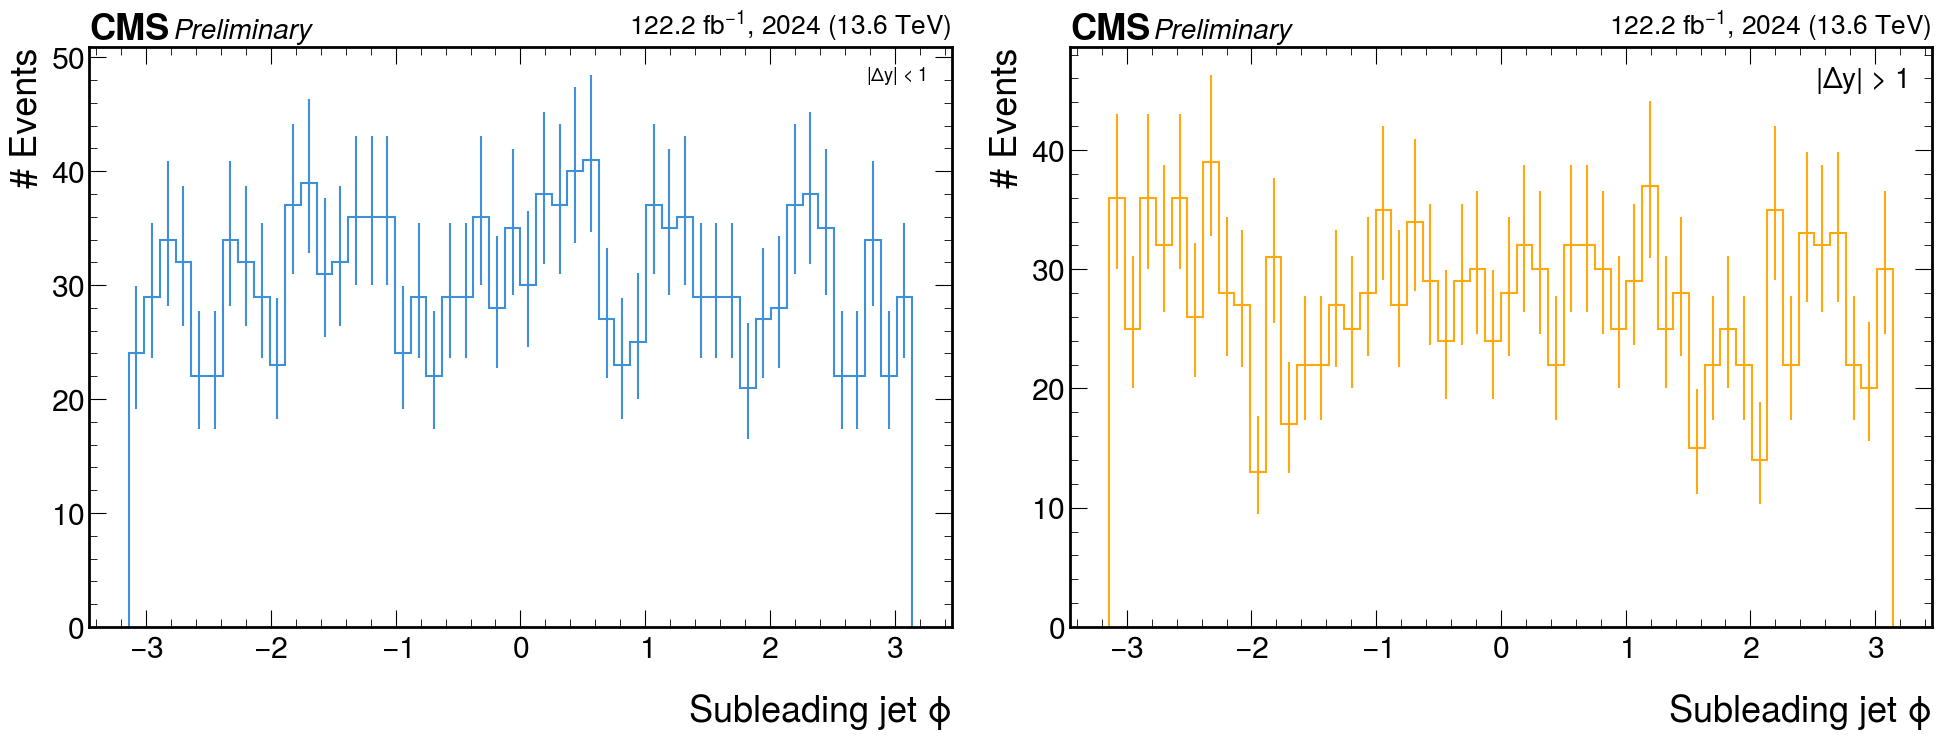

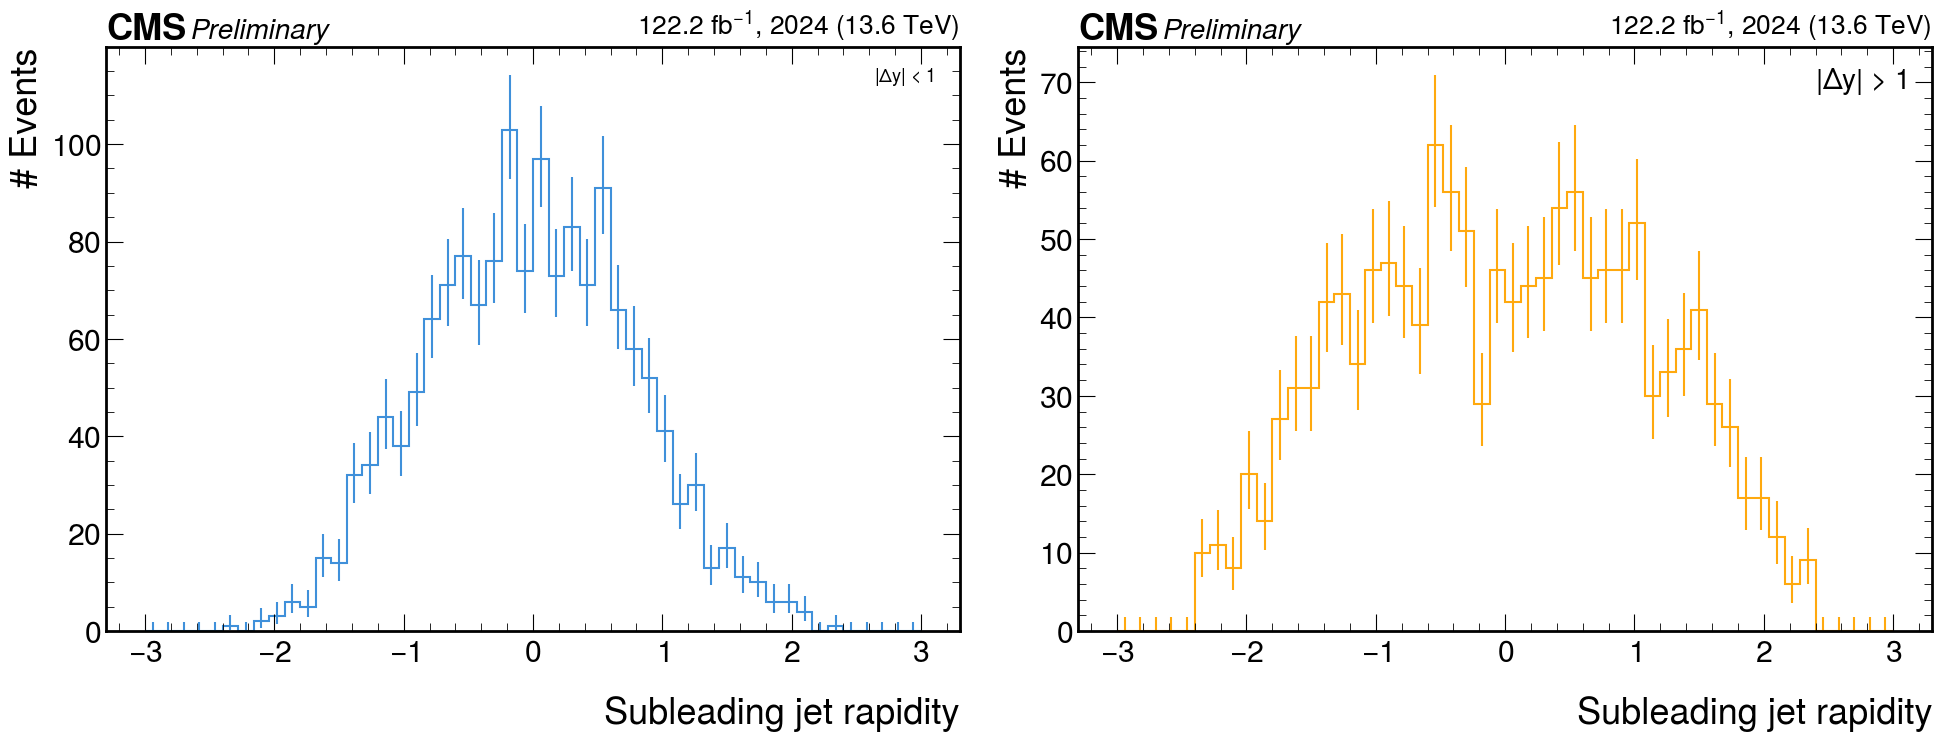

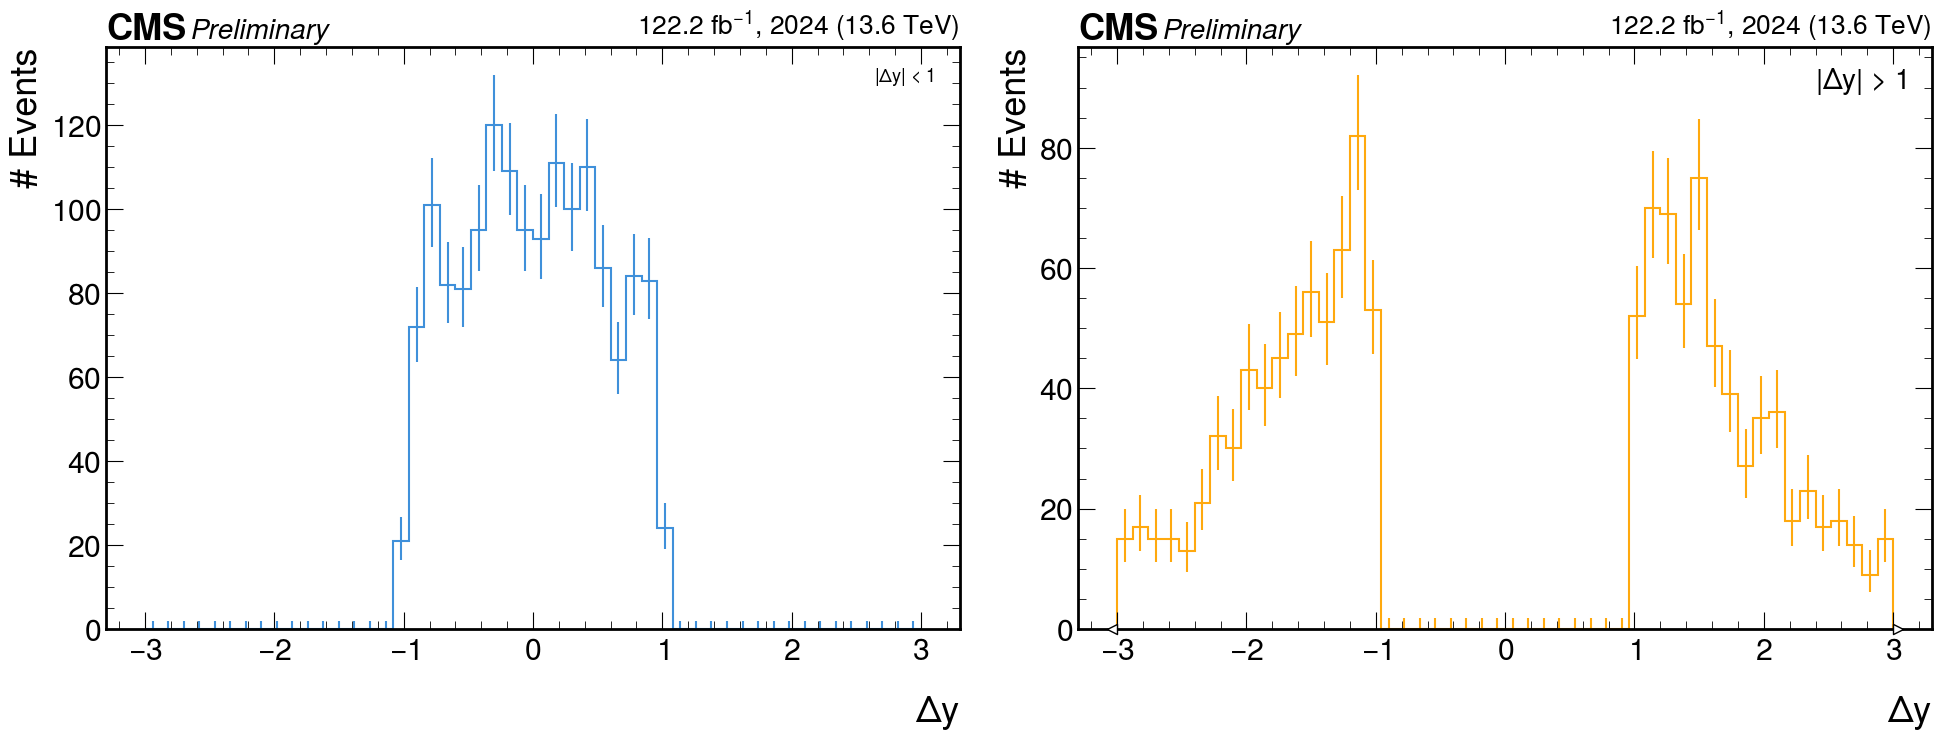

In [7]:
plot_specs = [
    ('ttbarmass', r'$m_{t\bar{t}}$ [GeV]'),
    ('jetmsd', r'Leading jet $m_{SD}$ [GeV]'),
    ('jetmsd1', r'Subleading jet $m_{SD}$ [GeV]'),
    ('jet0_pt', r'Leading jet $p_T$ [GeV]'),
    ('jet0_eta', r'Leading jet $\eta$'),
    ('jet0_phi', r'Leading jet $\phi$'),
    ('jet0_rapidity', r'Leading jet rapidity'),
    ('jet1_pt', r'Subleading jet $p_T$ [GeV]'),
    ('jet1_eta', r'Subleading jet $\eta$'),
    ('jet1_phi', r'Subleading jet $\phi$'),
    ('jet1_rapidity', r'Subleading jet rapidity'),
    ('jetdy', r'$\Delta y$'),
]

for var, xlabel in plot_specs:
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))

    h_cen = get_hist(var, anacat_id=0)
    h_fwd = get_hist(var, anacat_id=1)

    hep.histplot(h_cen, ax=ax1, histtype='step', color=CMS_COLORS[0])
    hplot.quick_label(xlabel=xlabel, data=True, ax=ax1)
    ax1.text(0.97, 0.97, r'|$\Delta y$| < 1', transform=ax1.transAxes,
             ha='right', va='top', fontsize=13)
    ax1.set_ylabel('# Events')
    ax1.set_xlabel(xlabel, labelpad=20)

    hep.histplot(h_fwd, ax=ax2, histtype='step', color=CMS_COLORS[1])
    hplot.quick_label(xlabel=xlabel, data=True, ax=ax2)
    ax2.text(0.97, 0.97, r'|$\Delta y$| > 1', transform=ax2.transAxes,
             ha='right', va='top', fontsize=20)
    ax2.set_ylabel('# Events')
    ax2.set_xlabel(xlabel, labelpad=20)

    plt.tight_layout()
    plt.show()

In [22]:
outputs[-1]['cutflow']

defaultdict_accumulator(int,
                        {'all events 1': 111585314,
                         'all events': 105519819,
                         'sumw': np.float64(105519819.0),
                         'sumw2': np.float64(105519819.0),
                         'atcen': 65,
                         'atfwd': 68,
                         '2tcen': 65,
                         '2tfwd': 50})